# 06 — Train aggregators (Phase 2, Step 11)

Обучаем 4 групповых агрегатора поверх замороженного SASRec на одном и том же split групп. Артефакты входа (Phase 1 чекпоинт + кэш скоров + аудио + user profiles) подгружаются с HF-датасета `Vladislavbro-500/music-recommendations`.

**Что делает ноутбук:**
1. Скачивает артефакты из HF в `artifacts/`.
2. Строит общий train/val split групп (10k / 2k, seed=42).
3. Тренирует AGREE → GroupIM → AudioAGREE → GroupCrossAttention. Конфиг каждого — в своей ячейке.
4. Сводная таблица + графики val NDCG@10 по эпохам.

**Test-eval не делаем здесь** — это шаг 12 (`07_eval_groups.ipynb`), чтобы не подсматривать в test при подборе конфигов.

In [1]:
# Colab bootstrap (раскомментировать в Colab):
from google.colab import userdata


token = userdata.get('git')
!git clone -q -b models-1 https://$token@github.com/Vladislavbro/music-recommendations.git
%cd music-recommendations
!pip install -q datasets pyarrow numpy pandas torch huggingface_hub

/content/music-recommendations


In [2]:
import os, sys, json, pickle, time
from pathlib import Path
import numpy as np
import pandas as pd
import torch


PROJECT_ROOT = Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))
print('project root:', PROJECT_ROOT)
print('cuda available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('device:', torch.cuda.get_device_name(0))

project root: /content/music-recommendations
cuda available: True
device: NVIDIA RTX PRO 6000 Blackwell Server Edition


In [3]:
# Подгружаем артефакты из HF-датасета `Vladislavbro-500/music-recommendations`.
# Локально (Mac) файлы уже есть — hf_hub_download просто вернёт путь из кэша/диска.
# На Colab скачает в artifacts/.
from huggingface_hub import hf_hub_download

HF_REPO = 'Vladislavbro-500/music-recommendations'
HF_REPO_TYPE = 'dataset'
ARTIFACTS = PROJECT_ROOT / 'artifacts'
ARTIFACTS.mkdir(parents=True, exist_ok=True)

needed = [
    'gsasrec/item_id_to_idx.pkl',
    'user_scores_cache/scores.parquet',
    'audio/embeddings.npy',
    'audio/user_profiles.npy',
    'audio/uid_to_row.pkl',
    'audio/user_audio_valid.npy',
]
for rel in needed:
    dst = ARTIFACTS / rel
    if dst.exists():
        print(f'  [skip]  {rel}  ({dst.stat().st_size / 2**20:.1f} MB)')
        continue
    print(f'  [pull]  {rel} ...', flush=True)
    p = hf_hub_download(
        repo_id=HF_REPO,
        repo_type=HF_REPO_TYPE,
        filename=rel,
        local_dir=str(ARTIFACTS),
    )
    print(f'           -> {p}')

  [pull]  gsasrec/item_id_to_idx.pkl ...


gsasrec/item_id_to_idx.pkl:   0%|          | 0.00/2.63M [00:00<?, ?B/s]

           -> /content/music-recommendations/artifacts/gsasrec/item_id_to_idx.pkl
  [pull]  user_scores_cache/scores.parquet ...


user_scores_cache/scores.parquet:   0%|          | 0.00/12.8M [00:00<?, ?B/s]

           -> /content/music-recommendations/artifacts/user_scores_cache/scores.parquet
  [pull]  audio/embeddings.npy ...


...

           -> /content/music-recommendations/artifacts/audio/user_profiles.npy
  [pull]  audio/uid_to_row.pkl ...


audio/uid_to_row.pkl:   0%|          | 0.00/72.1k [00:00<?, ?B/s]

           -> /content/music-recommendations/artifacts/audio/uid_to_row.pkl
  [pull]  audio/user_audio_valid.npy ...


audio/user_audio_valid.npy:   0%|          | 0.00/9.32k [00:00<?, ?B/s]

           -> /content/music-recommendations/artifacts/audio/user_audio_valid.npy


## 1. Shared setup

Здесь грузится всё, что не зависит от выбора агрегатора: данные, кэш скоров, аудио, синтез групп. Эти ячейки прогоняются один раз; ячейки методов (ниже) дёргают только подготовленные переменные.

In [4]:
# Загрузка YAMBDA-50m + GTS — повторяем протокол Phase 1, чтобы train/val/test
# совпали по timestamp-ам с тем, на чём учился скорер.
from grouprec.data.yambda_loader import (
    load_yambda, filter_listens, filter_min_popularity, apply_item_remap,
)
from grouprec.data.splits import global_temporal_split, SplitConfig

HF_CACHE = os.environ.get('HF_DATASETS_CACHE', None)
raw = load_yambda('50m', cache_dir=HF_CACHE)['interactions']
df = filter_listens(raw)
df = filter_min_popularity(df, min_count=5)

with open(ARTIFACTS / 'gsasrec' / 'item_id_to_idx.pkl', 'rb') as f:
    item_id_to_idx = pickle.load(f)
df = apply_item_remap(df, item_id_to_idx)
assert df['item_idx'].isna().sum() == 0
df['item_idx'] = df['item_idx'].astype('int64')
n_items = max(item_id_to_idx.values())

train_df, val_df, test_df = global_temporal_split(df, SplitConfig())
print(f'events: train={len(train_df):,}  val={len(val_df):,}  test={len(test_df):,}')
print(f'users: train={train_df["uid"].nunique():,}  val={val_df["uid"].nunique():,}  test={test_df["uid"].nunique():,}')
print(f'n_items (from item_id_to_idx): {n_items:,}')

README.md: 0.00B [00:00, ?B/s]

flat/50m/multi_event.parquet:   0%|          | 0.00/384M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/47790449 [00:00<?, ? examples/s]

events: train=28,524,373  val=139,455  test=153,140
users: train=9,194  val=4,596  test=4,576
n_items (from item_id_to_idx): 276,305


In [5]:
# Per-user score cache → user_topk (для построения C_G) и user_score_lookup
# (для per_user_scores в forward агрегатора).
from grouprec.eval.group_eval import topk_from_score_cache, test_targets_from_df
from grouprec.training.group_trainer import build_user_score_lookup

scores_df = pd.read_parquet(ARTIFACTS / 'user_scores_cache' / 'scores.parquet')
print('scores rows:', len(scores_df), '| uids:', scores_df['uid'].nunique(),
      '| K per uid:', int(scores_df.groupby('uid').size().iloc[0]))

t0 = time.time()
user_topk = topk_from_score_cache(scores_df)
user_score_lookup = build_user_score_lookup(scores_df)
print(f'built user_topk + score_lookup in {time.time()-t0:.1f}s, n_users={len(user_topk):,}')

scores rows: 1834000 | uids: 9170 | K per uid: 200
built user_topk + score_lookup in 0.5s, n_users=9,170


In [6]:
# Audio артефакты. ID-методам (AGREE, GroupIM) аудио не нужно, но Trainer
# принимает один и тот же набор тензоров — они их просто игнорируют.
item_audio = np.load(ARTIFACTS / 'audio' / 'embeddings.npy')
user_profiles = np.load(ARTIFACTS / 'audio' / 'user_profiles.npy')
with open(ARTIFACTS / 'audio' / 'uid_to_row.pkl', 'rb') as f:
    uid_to_row = pickle.load(f)

audio_valid_items = np.linalg.norm(item_audio, axis=1) > 0
print(f'item_audio: {item_audio.shape}, valid {int(audio_valid_items[1:].sum()):,}/{item_audio.shape[0]-1:,} '
      f'({100*audio_valid_items[1:].mean():.2f}%)')
print(f'user_profiles: {user_profiles.shape}, uid_to_row: {len(uid_to_row):,} entries')

item_audio: (276306, 128), valid 264,840/276,305 (95.85%)
user_profiles: (9194, 128), uid_to_row: 9,194 entries


In [7]:
# Per-user targets: train listens → ground-truth для train-групп,
# val listens → для val-групп. Test-таргеты НЕ собираем (шаг 12).
user_train_targets = test_targets_from_df(train_df)
user_val_targets = test_targets_from_df(val_df)
print(f'users with train listens: {len(user_train_targets):,}')
print(f'users with val   listens: {len(user_val_targets):,}')

users with train listens: 9,194
users with val   listens: 4,596


In [8]:
# Синтез групп. Pool — юзеры из кэша скоров (= train users минус <2-event filter).
# Размеры по литературе AGREE/GroupIM. Один seed → один и тот же split групп
# для всех 4 методов, чтобы сравнение было honest.
from grouprec.data.group_synthesis import synthesize_random_groups

GROUP_SEED = 42
N_TRAIN_GROUPS = 10_000
N_VAL_GROUPS = 2_000
N_TEST_GROUPS = 2_000  # понадобятся на шаге 12; синтезируем здесь, чтобы зафиксировать seed-split
SIZE_DIST = {2: 0.3, 3: 0.4, 4: 0.2, 5: 0.1}

user_pool = sorted(user_topk.keys())
rng = np.random.default_rng(GROUP_SEED)
train_groups = synthesize_random_groups(user_pool, N_TRAIN_GROUPS, SIZE_DIST, seed=int(rng.integers(1 << 30)))
val_groups   = synthesize_random_groups(user_pool, N_VAL_GROUPS,   SIZE_DIST, seed=int(rng.integers(1 << 30)))
test_groups  = synthesize_random_groups(user_pool, N_TEST_GROUPS,  SIZE_DIST, seed=int(rng.integers(1 << 30)))
print(f'pool={len(user_pool):,}  train_groups={len(train_groups)}  val_groups={len(val_groups)}  test_groups={len(test_groups)}')

pool=9,170  train_groups=10000  val_groups=2000  test_groups=2000


In [9]:
# Сборка GroupSample для train (target = train listens) и val (target = val listens).
# Test-samples собирать здесь не будем — но сами test_groups сохраним для шага 12.
from grouprec.eval.group_eval import build_group_samples

train_samples, train_stats = build_group_samples(
    train_groups, user_topk, user_train_targets,
    ground_truth='union', drop_empty=True, drop_missing_member=True,
)
val_samples, val_stats = build_group_samples(
    val_groups, user_topk, user_val_targets,
    ground_truth='union', drop_empty=True, drop_missing_member=True,
)
print('TRAIN:', {k: train_stats[k] for k in ['n_input_groups','n_kept','n_dropped_empty_targets','candidate_size_mean','target_size_mean','by_size_counts']})
print('VAL  :', {k: val_stats[k] for k in ['n_input_groups','n_kept','n_dropped_empty_targets','candidate_size_mean','target_size_mean','by_size_counts']})

# Сохраняем split групп — пригодится шагу 12 (test_groups в т.ч.).
AGG_DIR = ARTIFACTS / 'aggregators'
AGG_DIR.mkdir(parents=True, exist_ok=True)
with open(AGG_DIR / 'groups_split.pkl', 'wb') as f:
    pickle.dump({
        'train_groups': train_groups,
        'val_groups': val_groups,
        'test_groups': test_groups,
        'group_seed': GROUP_SEED,
        'size_dist': SIZE_DIST,
        'train_stats': train_stats,
        'val_stats': val_stats,
    }, f)
print(f'saved {AGG_DIR / "groups_split.pkl"}')

TRAIN: {'n_input_groups': 10000, 'n_kept': 10000, 'n_dropped_empty_targets': 0, 'candidate_size_mean': 578.9909, 'target_size_mean': 221.3116, 'by_size_counts': {2: 2990, 3: 3974, 4: 1967, 5: 1069}}
VAL  : {'n_input_groups': 2000, 'n_kept': 1542, 'n_dropped_empty_targets': 458, 'candidate_size_mean': 600.8307392996109, 'target_size_mean': 10.097924773022049, 'by_size_counts': {2: 368, 3: 642, 4: 334, 5: 198}}
saved /content/music-recommendations/artifacts/aggregators/groups_split.pkl


In [10]:
# Popularity-веса для negative sampling в trainer'е.
from grouprec.training.group_trainer import compute_pop_counts

pop_counts = compute_pop_counts(train_df, n_items=n_items, item_col='item_idx', smoothing=0.75)
print(f'pop_counts: shape={pop_counts.shape}, sum={pop_counts.sum():.3f}, max={pop_counts.max():.6f}')

pop_counts: shape=(276306,), sum=1.000, max=0.000329


## 2. Training

Общая часть — `GroupTrainConfig` с дефолтами + хелпер `make_trainer`. Каждый метод дальше переопределяет только то, что отличается.

In [23]:
from dataclasses import replace
from grouprec.training.group_trainer import GroupTrainConfig, GroupAggregatorTrainer
from grouprec.aggregators import IDBasedAGREE, GroupIM, AudioAGREE, GroupCrossAttention

BASE_CFG = GroupTrainConfig(
    n_epochs=100,
    batch_size=64,
    eval_batch_size=128,
    lr=1e-3,
    weight_decay=0.0,
    n_neg_per_pos=4,
    eval_k=(10, 20),
    early_stop_patience=30,
    seed=42,
    log_every_steps=50,
    device='cuda' if torch.cuda.is_available() else 'cpu',
)

def make_trainer(model, out_subdir, **cfg_overrides):
    cfg = replace(BASE_CFG, out_dir=str(AGG_DIR / out_subdir), **cfg_overrides)
    return GroupAggregatorTrainer(
        aggregator=model,
        cfg=cfg,
        user_score_lookup=user_score_lookup,
        pop_counts=pop_counts,
        item_audio=item_audio,
        user_profiles=user_profiles,
        uid_to_row=uid_to_row,
    )

print('base cfg device:', BASE_CFG.device)

base cfg device: cuda


### 2.1 ID-based AGREE

Item-aware attention `α_{u,i} = softmax(h^T tanh(W [e_u; e_i]))` на learnable ID-эмбеддингах. Группа: `s_G(i) = Σ_u α_{u,i} · s_{u,i}`.

In [24]:
torch.manual_seed(BASE_CFG.seed)
model_agree = IDBasedAGREE(
    uid_list=user_pool,
    num_items=n_items,
    d_emb=32,
    d_att=32,
)
trainer_agree = make_trainer(model_agree, 'agree')
n_params = sum(p.numel() for p in model_agree.parameters() if p.requires_grad)
print(f'AGREE params: {n_params:,}')

result_agree = trainer_agree.fit(train_samples, val_samples, verbose=True)
print('AGREE done:', {k: v for k, v in result_agree.items() if k != 'history'})

AGREE params: 9,137,376
  epoch 0 step 50/157 loss=0.6963
  epoch 0 step 100/157 loss=0.6977
  epoch 0 step 150/157 loss=0.6935
epoch 0: loss=0.6938 val_NDCG@10=0.0832 val_NDCG@20=0.0938 time=2.3s
  -> new best, saved /content/music-recommendations/artifacts/aggregators/agree/best.pt
  epoch 1 step 50/157 loss=0.6792
  epoch 1 step 100/157 loss=0.6814
  epoch 1 step 150/157 loss=0.6770
epoch 1: loss=0.6775 val_NDCG@10=0.0837 val_NDCG@20=0.0940 time=2.3s
  -> new best, saved /content/music-recommendations/artifacts/aggregators/agree/best.pt
  epoch 2 step 50/157 loss=0.6604
  epoch 2 step 100/157 loss=0.6645
  epoch 2 step 150/157 loss=0.6653
epoch 2: loss=0.6661 val_NDCG@10=0.0830 val_NDCG@20=0.0946 time=2.3s
  epoch 3 step 50/157 loss=0.6705
  epoch 3 step 100/157 loss=0.6685
  epoch 3 step 150/157 loss=0.6683
epoch 3: loss=0.6678 val_NDCG@10=0.0841 val_NDCG@20=0.0961 time=2.2s
  -> new best, saved /content/music-recommendations/artifacts/aggregators/agree/best.pt
  epoch 4 step 50/15

### 2.2 GroupIM

Item-agnostic attention + MI-регуляризация. `reg_loss_weight=0.5` — середина сетки `{0.1, 0.5, 1.0}` из открытых вопросов лога. Если основная таблица покажет, что GroupIM сильно проигрывает — попробуем другие λ.

In [25]:
torch.manual_seed(BASE_CFG.seed)
model_groupim = GroupIM(
    uid_list=user_pool,
    num_items=n_items,
    d_emb=32,
    d_att=32,
)
trainer_groupim = make_trainer(model_groupim, 'groupim', reg_loss_weight=0.5)
n_params = sum(p.numel() for p in model_groupim.parameters() if p.requires_grad)
print(f'GroupIM params: {n_params:,}, λ_MI=0.5')

result_groupim = trainer_groupim.fit(train_samples, val_samples, verbose=True)
print('GroupIM done:', {k: v for k, v in result_groupim.items() if k != 'history'})

GroupIM params: 295,584, λ_MI=0.5
  epoch 0 step 50/157 loss=1.3748
  epoch 0 step 100/157 loss=1.3805
  epoch 0 step 150/157 loss=1.3800
epoch 0: loss=1.3812 val_NDCG@10=0.0825 val_NDCG@20=0.0934 time=2.3s
  -> new best, saved /content/music-recommendations/artifacts/aggregators/groupim/best.pt
  epoch 1 step 50/157 loss=1.3827
  epoch 1 step 100/157 loss=1.3772
  epoch 1 step 150/157 loss=1.3712
epoch 1: loss=1.3713 val_NDCG@10=0.0827 val_NDCG@20=0.0939 time=2.3s
  -> new best, saved /content/music-recommendations/artifacts/aggregators/groupim/best.pt
  epoch 2 step 50/157 loss=1.3627
  epoch 2 step 100/157 loss=1.3552
  epoch 2 step 150/157 loss=1.3516
epoch 2: loss=1.3517 val_NDCG@10=0.0828 val_NDCG@20=0.0943 time=2.3s
  -> new best, saved /content/music-recommendations/artifacts/aggregators/groupim/best.pt
  epoch 3 step 50/157 loss=1.3347
  epoch 3 step 100/157 loss=1.3301
  epoch 3 step 150/157 loss=1.3297
epoch 3: loss=1.3288 val_NDCG@10=0.0829 val_NDCG@20=0.0951 time=2.3s
  ->


### 2.3 AudioAGREE

Прямой аналог AGREE на аудио: `α_{u,i} = softmax(φ([ā_u; a_i]))`, φ — 2-слойный MLP с GELU. ID-эмбеддингов нет.

In [26]:
torch.manual_seed(BASE_CFG.seed)
model_aa = AudioAGREE(
    d_audio=128,
    d_att=64,
)
trainer_aa = make_trainer(model_aa, 'audio_agree')
n_params = sum(p.numel() for p in model_aa.parameters() if p.requires_grad)
print(f'AudioAGREE params: {n_params:,}')

result_aa = trainer_aa.fit(train_samples, val_samples, verbose=True)
print('AudioAGREE done:', {k: v for k, v in result_aa.items() if k != 'history'})

AudioAGREE params: 16,512
  epoch 0 step 50/157 loss=0.7678
  epoch 0 step 100/157 loss=0.7489
  epoch 0 step 150/157 loss=0.7363
epoch 0: loss=0.7363 val_NDCG@10=0.0757 val_NDCG@20=0.0871 time=2.3s
  -> new best, saved /content/music-recommendations/artifacts/aggregators/audio_agree/best.pt
  epoch 1 step 50/157 loss=0.6987
  epoch 1 step 100/157 loss=0.6934
  epoch 1 step 150/157 loss=0.6956
epoch 1: loss=0.6928 val_NDCG@10=0.0794 val_NDCG@20=0.0899 time=2.3s
  -> new best, saved /content/music-recommendations/artifacts/aggregators/audio_agree/best.pt
  epoch 2 step 50/157 loss=0.6777
  epoch 2 step 100/157 loss=0.6813
  epoch 2 step 150/157 loss=0.6811
epoch 2: loss=0.6801 val_NDCG@10=0.0851 val_NDCG@20=0.0958 time=2.3s
  -> new best, saved /content/music-recommendations/artifacts/aggregators/audio_agree/best.pt
  epoch 3 step 50/157 loss=0.6718
  epoch 3 step 100/157 loss=0.6759
  epoch 3 step 150/157 loss=0.6775
epoch 3: loss=0.6773 val_NDCG@10=0.0906 val_NDCG@20=0.1017 time=2.3s


### 2.4 GroupCrossAttention

Multi-head scaled dot-product cross-attention с `Q = a_i, K = ā_u`. Логиты усредняются по головам, итог = `Σ_u α_{u,i} · s_{u,i}` (как у всех остальных).

In [27]:
torch.manual_seed(BASE_CFG.seed)
model_ca = GroupCrossAttention(
    d_audio=128,
    d_model=64,
    n_heads=4,
)
trainer_ca = make_trainer(model_ca, 'group_cross_attn')
n_params = sum(p.numel() for p in model_ca.parameters() if p.requires_grad)
print(f'GroupCrossAttention params: {n_params:,}')

result_ca = trainer_ca.fit(train_samples, val_samples, verbose=True)
print('GroupCrossAttention done:', {k: v for k, v in result_ca.items() if k != 'history'})

GroupCrossAttention params: 16,512
  epoch 0 step 50/157 loss=0.7881
  epoch 0 step 100/157 loss=0.7830
  epoch 0 step 150/157 loss=0.7727
epoch 0: loss=0.7723 val_NDCG@10=0.0718 val_NDCG@20=0.0822 time=2.3s
  -> new best, saved /content/music-recommendations/artifacts/aggregators/group_cross_attn/best.pt
  epoch 1 step 50/157 loss=0.7520
  epoch 1 step 100/157 loss=0.7536
  epoch 1 step 150/157 loss=0.7541
epoch 1: loss=0.7559 val_NDCG@10=0.0784 val_NDCG@20=0.0867 time=2.3s
  -> new best, saved /content/music-recommendations/artifacts/aggregators/group_cross_attn/best.pt
  epoch 2 step 50/157 loss=0.7570
  epoch 2 step 100/157 loss=0.7525
  epoch 2 step 150/157 loss=0.7558
epoch 2: loss=0.7547 val_NDCG@10=0.0807 val_NDCG@20=0.0915 time=2.3s
  -> new best, saved /content/music-recommendations/artifacts/aggregators/group_cross_attn/best.pt
  epoch 3 step 50/157 loss=0.7364
  epoch 3 step 100/157 loss=0.7371
  epoch 3 step 150/157 loss=0.7344
epoch 3: loss=0.7348 val_NDCG@10=0.0805 val_N

## 3. Comparison (val only)

Test трогать не будем (это шаг 12). Здесь — сравнение **по val** + кривые обучения.

In [31]:
# Сводная таблица: best val NDCG@10/20 per method (читаем metrics.csv).
rows = []
for name, subdir in [
    ('AGREE',           'agree'),
    ('GroupIM',         'groupim'),
    ('AudioAGREE',      'audio_agree'),
    ('GroupCrossAttn',  'group_cross_attn'),
]:
    mp = AGG_DIR / subdir / 'metrics.csv'
    if not mp.exists():
        rows.append({'method': name, 'best_epoch': None, 'val_NDCG@10': None})
        continue
    m = pd.read_csv(mp)
    best_row = m.iloc[m['val_NDCG@10'].idxmax()]
    rows.append({
        'method': name,
        'best_epoch': int(best_row['epoch']),
        'val_NDCG@10': float(best_row['val_NDCG@10']),
        'epochs_run': len(m),
    })
summary = pd.DataFrame(rows).sort_values('val_NDCG@10', ascending=False)
print(summary.to_string(index=False))

        method  best_epoch  val_NDCG@10  epochs_run
    AudioAGREE          66     0.097774          97
GroupCrossAttn          53     0.094130          84
         AGREE          20     0.091642          51
       GroupIM          50     0.091083          81


In [32]:
# Доп. таблица: финальный val NDCG@20 (пересчитываем через trainer.evaluate на best.pt).
from grouprec.eval.group_eval import evaluate_aggregator_scores

def reload_and_eval(model, trainer, ckpt_path):
    sd = torch.load(ckpt_path, map_location=trainer.device)
    model.load_state_dict(sd['aggregator_state'])
    return trainer.evaluate(val_samples)

final = []
for name, model, trainer in [
    ('AGREE',           model_agree,   trainer_agree),
    ('GroupIM',         model_groupim, trainer_groupim),
    ('AudioAGREE',      model_aa,      trainer_aa),
    ('GroupCrossAttn',  model_ca,      trainer_ca),
]:
    ckpt = Path(trainer.cfg.out_dir) / 'best.pt'
    if not ckpt.exists():
        continue
    m = reload_and_eval(model, trainer, ckpt)
    final.append({
        'method': name,
        'val_NDCG@10': m['NDCG@10'],
        'val_NDCG@20': m['NDCG@20'],
        'val_NDCG@10_std': m['NDCG@10_std'],
        **{f'NDCG@10[size={s}]': m['by_size'][s]['NDCG@10'] for s in sorted(m['by_size'])},
    })
final_df = pd.DataFrame(final).sort_values('val_NDCG@10', ascending=False)
print(final_df.to_string(index=False))

        method  val_NDCG@10  val_NDCG@20  val_NDCG@10_std  NDCG@10[size=2]  NDCG@10[size=3]  NDCG@10[size=4]  NDCG@10[size=5]
    AudioAGREE     0.097774     0.109667         0.166035         0.134818         0.094074         0.079998         0.070906
GroupCrossAttn     0.094130     0.105606         0.163551         0.119349         0.094481         0.080611         0.068923
         AGREE     0.091642     0.102439         0.163074         0.125508         0.090010         0.074119         0.063548
       GroupIM     0.091083     0.102679         0.162892         0.125019         0.089065         0.069762         0.070515


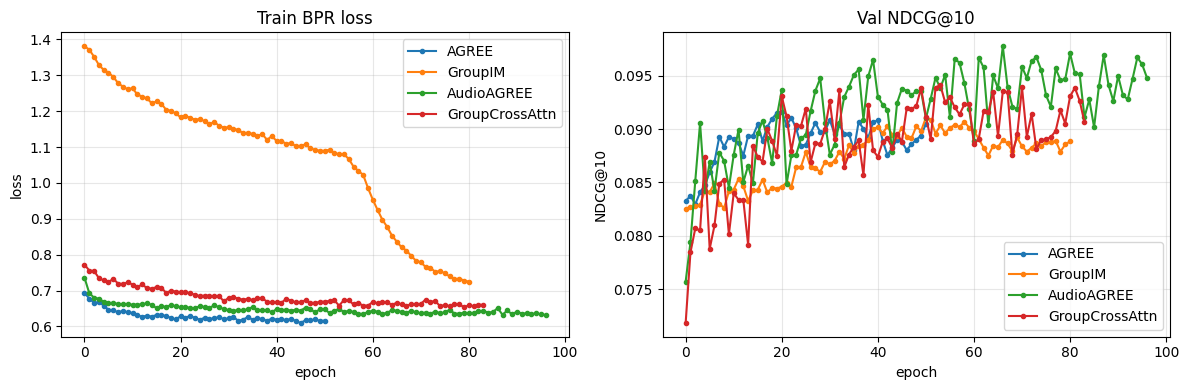

In [33]:
# График train loss + val NDCG@10 по эпохам для всех 4 методов.
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
methods = [
    ('AGREE',           'agree'),
    ('GroupIM',         'groupim'),
    ('AudioAGREE',      'audio_agree'),
    ('GroupCrossAttn',  'group_cross_attn'),
]
for name, subdir in methods:
    mp = AGG_DIR / subdir / 'metrics.csv'
    if not mp.exists():
        continue
    m = pd.read_csv(mp)
    axes[0].plot(m['epoch'], m['train_loss'], marker='o', markersize=3, label=name)
    axes[1].plot(m['epoch'], m['val_NDCG@10'], marker='o', markersize=3, label=name)
axes[0].set_title('Train BPR loss'); axes[0].set_xlabel('epoch'); axes[0].set_ylabel('loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].set_title('Val NDCG@10');    axes[1].set_xlabel('epoch'); axes[1].set_ylabel('NDCG@10'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 4. Что дальше

После прогона на Colab — залить `artifacts/aggregators/` обратно на HF, чтобы шаг 12 видел чекпоинты:

```
hf upload Vladislavbro-500/music-recommendations \
    artifacts/aggregators . \
    --type dataset --commit-message 'phase2 step11: aggregator checkpoints'
```

Шаг 12 (`07_eval_groups.ipynb`) подгрузит `groups_split.pkl` + 4 `best.pt`, посчитает test NDCG@10/20 + bootstrap CI + срез по размеру группы — это и есть финальная таблица для текста ВКР.

In [44]:
os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")
!hf upload Vladislavbro-500/music-recommendations \
    artifacts . \
    --type dataset \
    --commit-message 'phase2 step11: aggregator checkpoints'

Start hashing 19 files.
Finished hashing 19 files.
Processing Files (0 / 0)      : |          |  0.00B /  0.00B            
New Data Upload               : |          |  0.00B /  0.00B            

  .../group_cross_attn/best.pt: 100% 68.7k/68.7k [00:00<?, ?B/s]


  ...ators/audio_agree/best.pt: 100% 68.5k/68.5k [00:00<?, ?B/s]



  ...regators/groups_split.pkl: 100% 268k/268k [00:00<?, ?B/s]




  ...gregators/groupim/best.pt: 100% 1.26M/1.26M [00:00<?, ?B/s]





  ...aggregators/agree/best.pt: 100% 36.6M/36.6M [00:00<?, ?B/s]

  .../group_cross_attn/best.pt: 100% 68.7k/68.7k [00:00<?, ?B/s]


  ...ators/audio_agree/best.pt: 100% 68.5k/68.5k [00:00<?, ?B/s]



  ...regators/groups_split.pkl: 100% 268k/268k [00:00<?, ?B/s]




  ...gregators/groupim/best.pt: 100% 1.26M/1.26M [00:00<?, ?B/s]





Processing Files (5 / 5)      :  19% 38.3M/200M [00:00<00:00, 181MB/s,   ???B/s  ]

  .../group_cross_attn/best.pt: 100% 68.7k/68.7k [00:00<?, ?B/s]


  ...ators/audio_agree/best.pt: 100% 68.5